In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint #科学计算.统计学 import 离散随机分布

In [8]:
a = 1
b = 6

In [11]:
x = np.arange(a,b + 1)
discrete_uniform = randint(a,b+1)

In [12]:
p_x = discrete_uniform.pmf(x)

In [13]:
E_x = np.sum(p_x * x)

(0.0, 0.2)

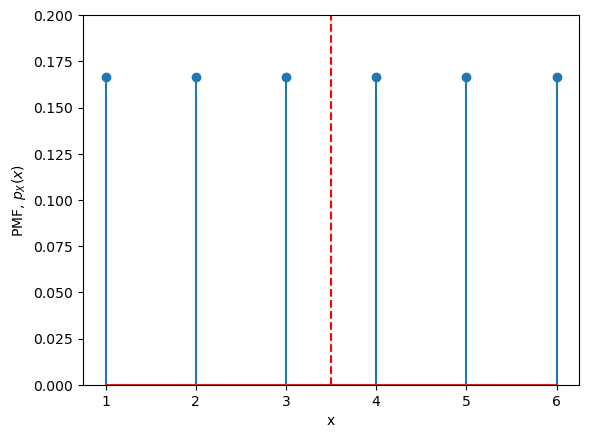

In [17]:
fig,ax = plt.subplots()

plt.stem(x,p_x)
plt.axvline(x = E_x,color = 'r',linestyle = '--')

plt.xticks(np.arange(a, b+1)) # 设置x轴刻度
plt.xlabel('x') # 设置x轴标签
plt.ylabel('PMF, $p_X(x)$') # 设置y轴标签
plt.ylim([0, 0.2]) # 设置y轴范围

In [19]:
from mpmath import mp #多精度数学
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
mp.dps = 1024 + 1 #配置总精度为1025位
digits = str(mp.pi)[2:]#变为字符串,提取小数部分
len(digits)

1024

In [22]:
digits_list = [int(x) for x in digits]

In [23]:
digits_array = np.array(digits_list)

In [24]:
digits_matrix = digits_array.reshape((32,32))

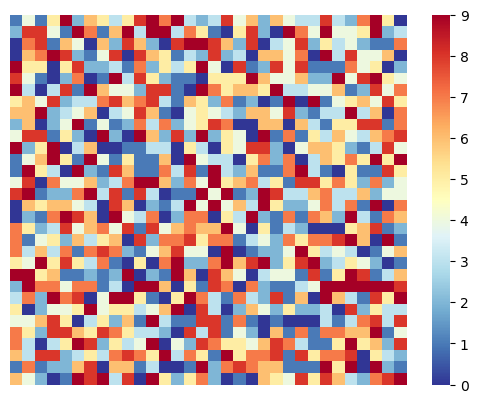

In [25]:
fig,ax = plt.subplots()

ax = sns.heatmap(digits_matrix,vmin = 0,vmax = 9,
                 cmap = 'RdYlBu_r',
                 yticklabels = False,
                 xticklabels = False)

ax.set_aspect('equal')
ax.tickparams(left = False,bottom = False)

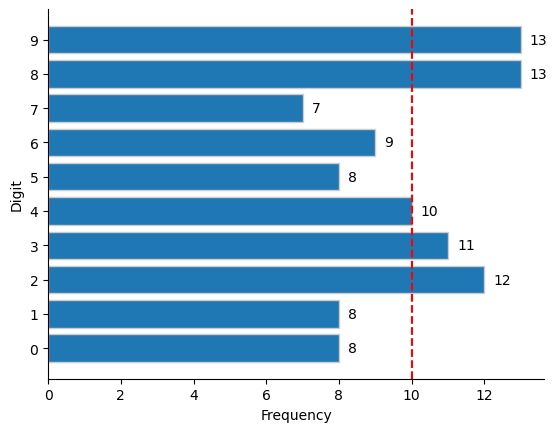

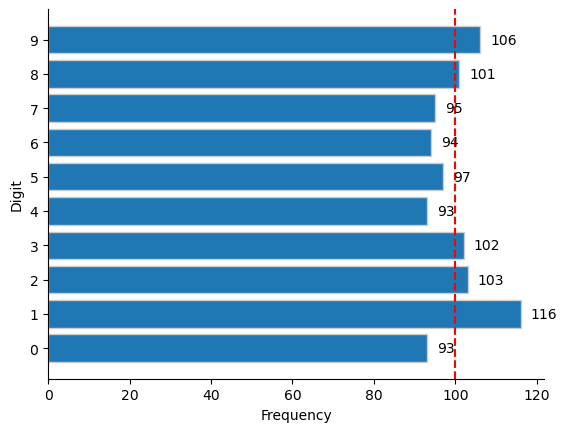

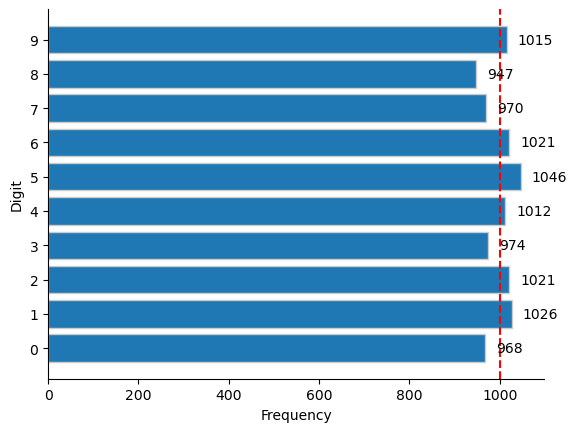

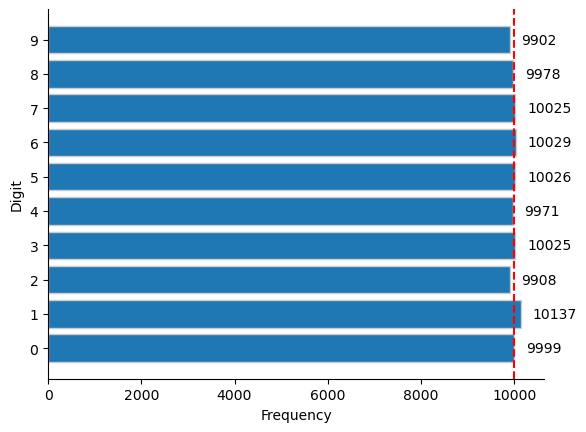

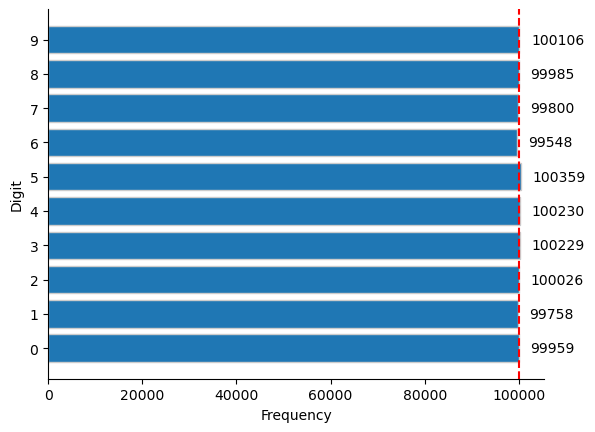

In [37]:
num_digits_array = [100,1000,10000,100000,1000000]

for num_digits in num_digits_array:
    mp.dps = num_digits + 1
    digits = str(mp.pi)[2:]

    digits_list = [int(x) for x in digits]
    digits_array = np.array(digits_list)

    fig,ax = plt.subplots()

    #返回之前的值对应索引,之前的值的频数对应值的列表
    counts = np.bincount(digits_array)
    #水平条形图,第一个是y值,第二个是x值 align条中心对齐到刻度
    ax.barh(range(10),counts,align = 'center',edgecolor = '0.8')

    for i,v in enumerate(counts):
        ax.text(v + num_digits/400,i,str(v),color = 'k',va = 'center')

    ax.axvline(x=num_digits/10, color='r', linestyle='--') # 绘制红色虚线表示理论频率
    plt.yticks(range(10)) # 设置y轴刻度
    ax.spines['top'].set_visible(False) # 隐藏顶部边框
    ax.spines['right'].set_visible(False) # 隐藏右侧边框
    ax.set_xlabel('Frequency') # 设置x轴标签
    ax.set_ylabel('Digit') # 设置y轴标签

In [38]:
from scipy.stats import binom #导入二项式分布
import matplotlib.pyplot as plt
import numpy as np

In [39]:
KK = [1,2,3,4,8,16,32,64]
p = 0.7

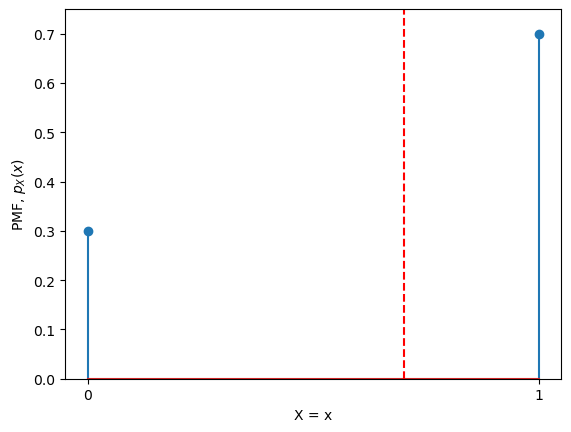

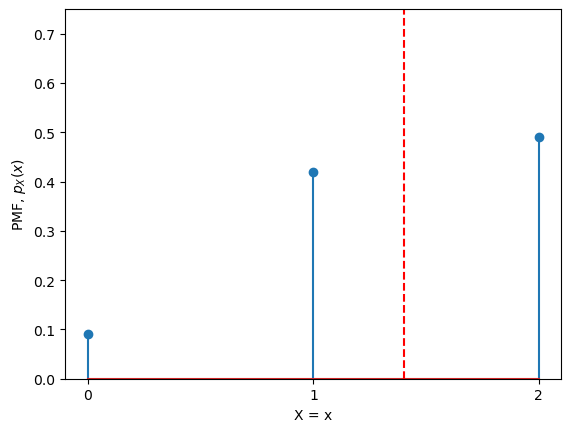

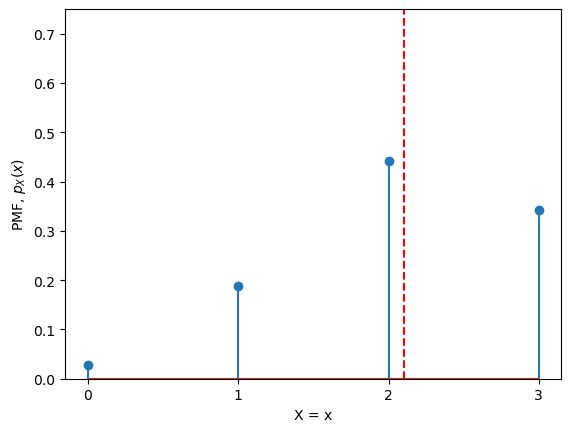

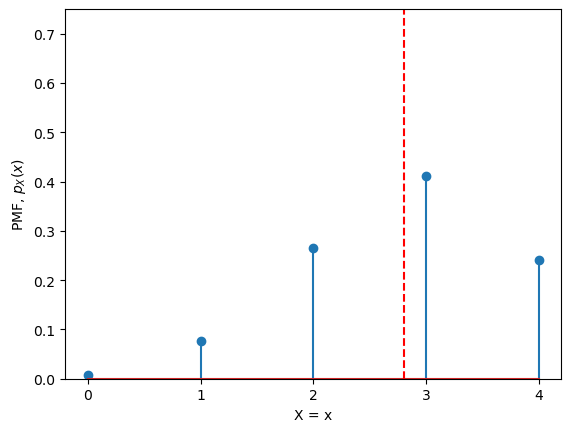

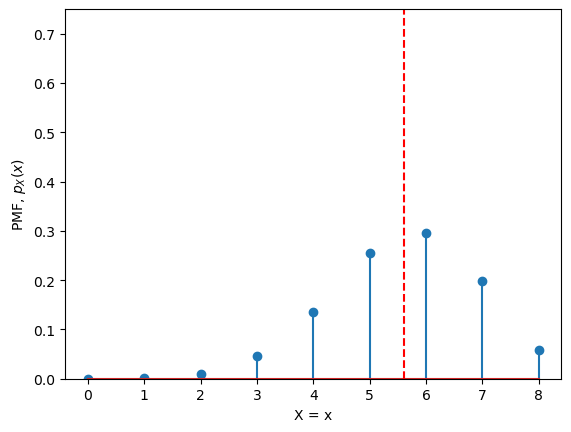

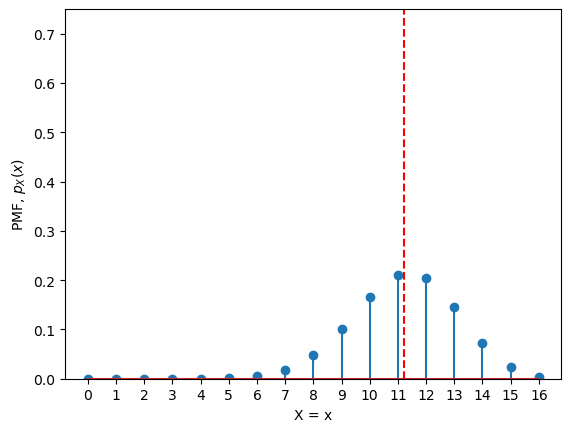

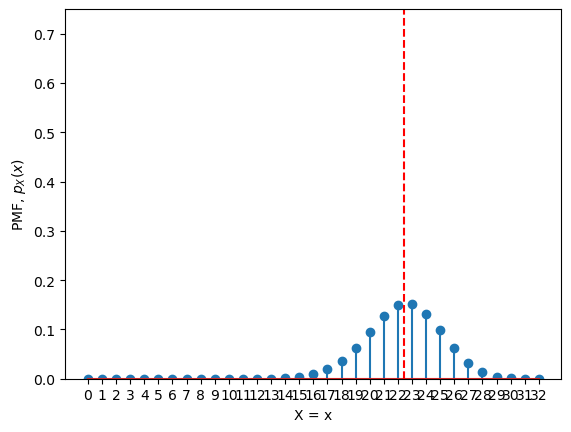

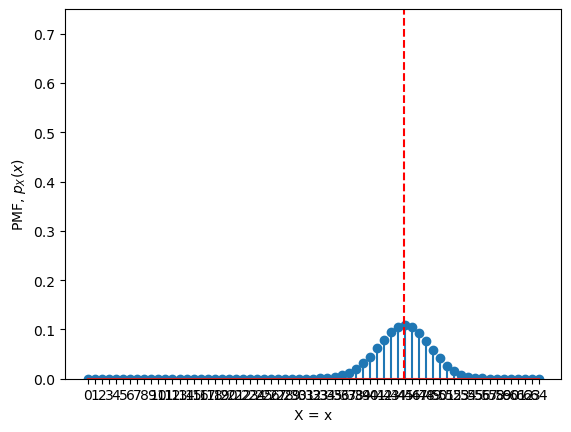

In [41]:
for K in KK:
    x = np.arange(0,K+1)

    #x是计算概率的取值,K是实验次数,p是概率
    #其实K和p就能求所有,但是为了方便还是配置了x,x是我们需要获得的,这里取了全部数据作为x
    p_x = binom.pmf(x,K,p)

    E_x = np.sum(p_x * x)

    fig,ax = plt.subplots()
    plt.stem(x,p_x)
    plt.axvline(x = E_x,color = 'r',linestyle = '--')

    
    plt.xticks(np.arange(K + 1)) # 设置x轴刻度
    plt.xlabel('X = x') # 设置x轴标签
    plt.ylabel('PMF, $p_X(x)$') # 设置y轴标签
    plt.ylim([0, p + 0.05]) # 设置y轴范围

In [43]:
from scipy.stats import multinomial
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [45]:
num = 8
x1_array = np.arange(num + 1)
x2_array = np.arange(num + 1)

xx1,xx2 = np.meshgrid(x1_array,x2_array)

xx3 = num - xx1 - xx2
#注意xx3已经是2D数组了
#where里面进行判断,第一个是判断语句,如果为true,对应位置赋值xx3,为False赋值nan
    #第一个判断得到的是一个布尔2D数组,这里对比2D数组的大小和赋值矩阵大小,其次看对应位置赋值
xx3 = np.where(xx3 >= 0.0 ,xx3,np.nan)

In [70]:
def heatmap_sum(data,i_array,j_array,title,vmin,vmax,cmap,annot = False):
    fig,ax = plt.subplots(figsize = (10,10))
    ax = sns.heatmap(data,cmap = cmap,
                     cbar_kws = {'orientation':'horizontal'},
                     yticklabels = i_array,xticklabels = j_array,
                     ax = ax,annot = annot,
                     linewidth = 0.25,linecolor = 'grey',
                     vmin = vmin,vmax = vmax,
                     fmt = '.3f'
                    )
    ax.set_xlabel('$x_1$') # 设置x轴标签
    ax.set_ylabel('$x_2$') # 设置y轴标签
    ax.invert_yaxis() # 反转y轴
    ax.set_aspect("equal") # 设置坐标系比例
    plt.title(title) # 设置标题
    plt.yticks(rotation=0) # 设置y轴标签旋转角度

In [71]:
p_array = [0.1,0.6,0.3]
PMF_ff = multinomial.pmf(x = np.array(([xx1.ravel(),xx2.ravel(),xx3.ravel()])).T,
                         n = num,p = p_array)
PMF_ff = np.where(PMF_ff > 0.0,PMF_ff,np.nan)
PMF_ff = np.reshape(PMF_ff,xx1.shape)

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_multivariate.py:4036: RuntimeWarning: invalid value encountered in cast
  xx = np.asarray(x, dtype=int)


In [72]:
df = pd.DataFrame(np.flipud(PMF_ff))#上下翻转

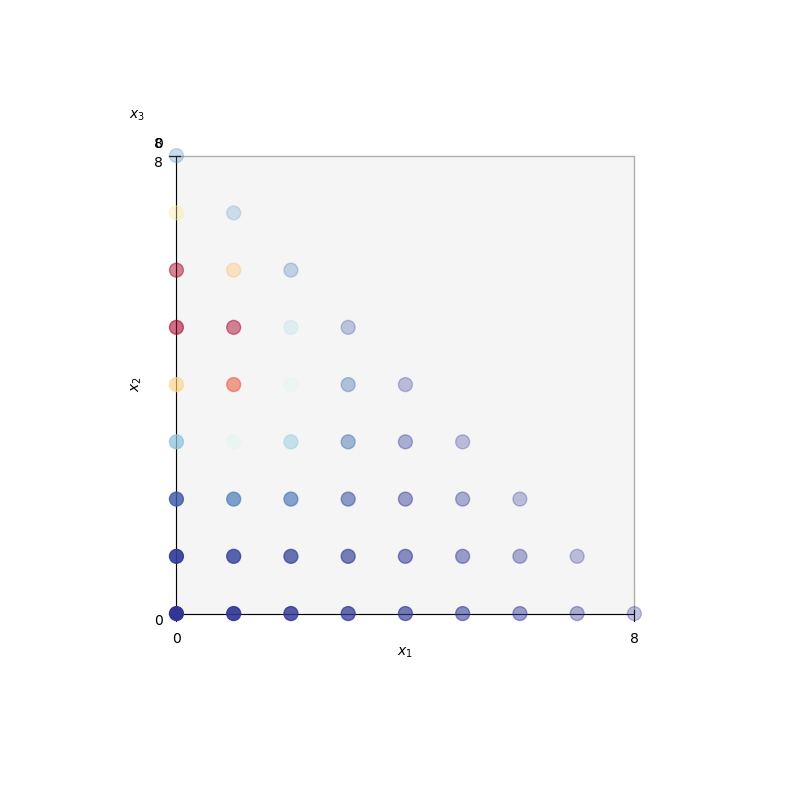

In [73]:
fig = plt.figure(figsize = (10,10))
ax = plt.axes(projection = '3d')

ax.scatter3D(xx1.ravel(),xx2.ravel(),xx3.ravel(),
             s = 400,marker = '.',c = PMF_ff.ravel(),cmap = 'RdYlBu_r')

ax.set_proj_type('ortho') # 设置正交投影
ax.set_xlabel('$x_1$') # 设置x轴标签
ax.set_ylabel('$x_2$') # 设置y轴标签
ax.set_zlabel('$x_3$') # 设置z轴标签
# ax.w_xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0)) # 设置x轴面板颜色
# ax.w_yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0)) # 设置y轴面板颜色
# ax.w_zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0)) # 设置z轴面板颜色

ax.set_xticks([0, num]) # 设置x轴刻度
ax.set_yticks([0, num]) # 设置y轴刻度
ax.set_zticks([0, num]) # 设置z轴刻度

ax.set_xlim(0, num) # 设置x轴范围
ax.set_ylim(0, num) # 设置y轴范围
ax.set_zlim3d(0, num) # 设置z轴范围
ax.view_init(azim=-90, elev=90) # 设置视角
ax.set_box_aspect(aspect=(1, 1, 1)) # 设置坐标轴比例
ax.grid() # 显示网格
plt.show() # 显示图形

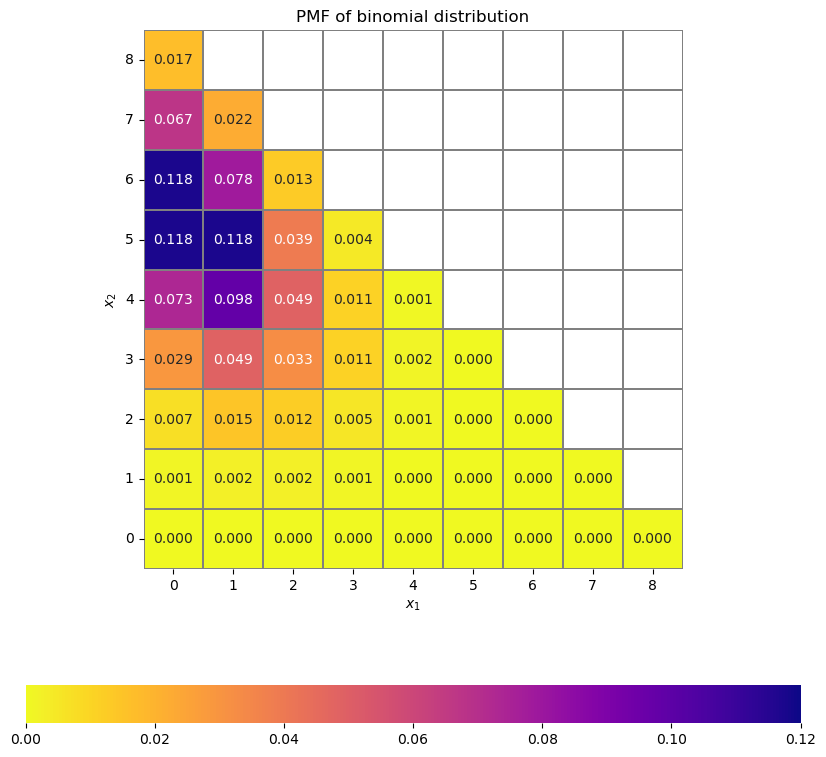

In [74]:
title = 'PMF of binomial distribution'
heatmap_sum(PMF_ff,x1_array,x2_array,title,0,0.12,'plasma_r',True)

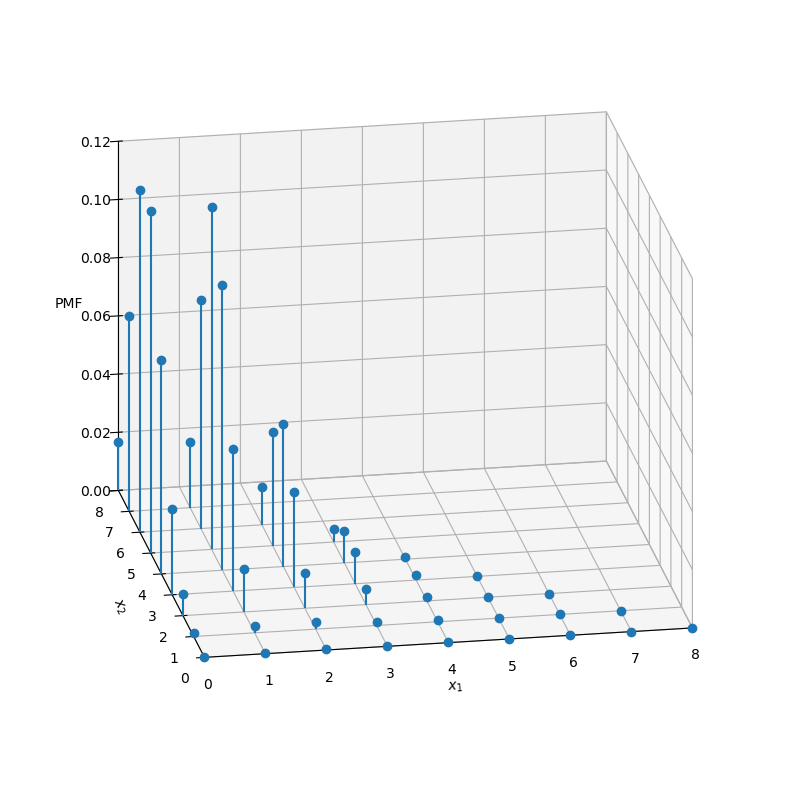

In [82]:
fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(111,projection = '3d')

#隐藏基线
#因为ravel了,按理说基线只出现在绘制点的下面,这里ravel让这里的点连起来了
ax.stem(xx1.ravel(),xx2.ravel(),PMF_ff.ravel(),basefmt = ' ')

ax.set_xlabel('$x_1$') # 设置x轴标签
ax.set_ylabel('$x_2$') # 设置y轴标签
ax.set_zlabel('PMF') # 设置z轴标签

ax.set_xlim((0, 8)) # 设置x轴范围
ax.set_ylim((0, 8)) # 设置y轴范围
ax.set_zlim((0, 0.12)) # 设置z轴范围
ax.view_init(azim=-100, elev=20) # 设置视角
ax.set_proj_type('ortho') # 设置正交投影
plt.show() # 显示图形

In [83]:
from scipy.stats import poisson
import matplotlib.pyplot as plt
import numpy as np

In [84]:
p = plt.rcParams  # 获取默认绘图参数
p["font.weight"] = "light"  # 设置字体粗细为 light
p["ytick.minor.visible"] = True  # 显示 y 轴的小刻度
p["xtick.minor.visible"] = True  # 显示 x 轴的小刻度
p["axes.grid"] = True  # 启用坐标轴网格
p["grid.color"] = "0.5"  # 设置网格颜色为灰色
p["grid.linewidth"] = 0.5  # 设置网格线宽度

In [85]:
x_array = np.arange(0,20 + 1)

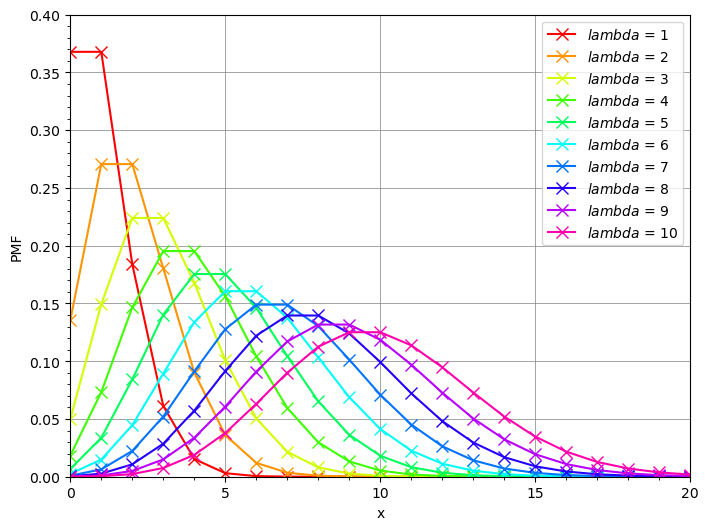

In [89]:
fig,ax = plt.subplots(figsize = (8,6))

lambda_values = [1,2,3,4,5,6,7,8,9,10]
num_colors = len(lambda_values)

for idx,lambda_ in enumerate(lambda_values):
    color = plt.cm.hsv(idx / num_colors)
    plt.plot(
        x_array,
        poisson.pmf(x_array,lambda_),
        marker = 'x',
        markersize = 8,
        label = r'$lambda$ = ' + str(lambda_),
        color = color
    )

plt.xlabel('x')  # 设置x轴标签
plt.ylabel('PMF')  # 设置y轴标签
# plt.gca().spines['right'].set_visible(False)  # 隐藏右边框
# plt.gca().spines['top'].set_visible(False)  # 隐藏上边框
# plt.gca().yaxis.set_ticks_position('left')  # y轴刻度在左侧
# plt.gca().xaxis.set_ticks_position('bottom')  # x轴刻度在底部
plt.xlim(0, x_array.max())  # 设置x轴范围
plt.ylim(0, 0.4)  # 设置y轴范围
plt.xticks([0, 5, 10, 15, 20])  # 设置x轴刻度
plt.legend()  # 显示图例
plt.show()  # 显示图形

In [93]:
from scipy.stats import geom
import matplotlib.pyplot as plt
import numpy as np

p = plt.rcParams  # 获取默认绘图参数
p["font.weight"] = "light"  # 设置字体粗细为 light
p["ytick.minor.visible"] = True  # 显示 y 轴的小刻度
p["xtick.minor.visible"] = True  # 显示 x 轴的小刻度
p["axes.grid"] = True  # 启用坐标轴网格
p["grid.color"] = "0.5"  # 设置网格颜色为灰色
p["grid.linewidth"] = 0.5  # 设置网格线宽度

In [94]:
k_range = np.arange(1,21)

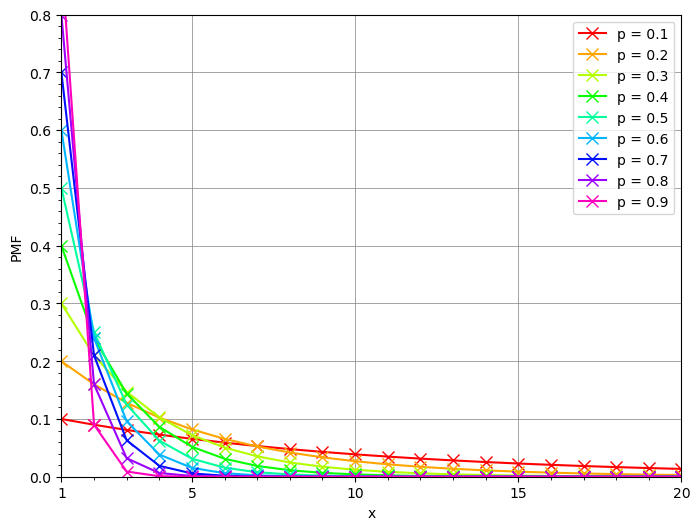

In [97]:
fig,ax = plt.subplots(figsize = (8,6))

p_values = np.arange(0.1,1.0,0.1)
num_colors = len(p_values)

for idx,p in enumerate(p_values):
    color = plt.cm.hsv(idx/num_colors)
    plt.plot(
        k_range,
        geom.pmf(k_range,p),
        marker = 'x',
        markersize = 8,
        label = 'p = {:.1f}'.format(p),
        color = color
    )

plt.xlabel('x')  # 设置x轴标签
plt.ylabel('PMF')  # 设置y轴标签
plt.xlim(1, k_range.max())  # 设置x轴范围
plt.ylim(0, 0.8)  # 设置y轴范围
plt.xticks([1, 5, 10, 15, 20])  # 设置x轴刻度
plt.legend()  # 显示图例
plt.show()  # 显示图形